In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [2]:
summary = pd.read_csv("../results/profiling_summary.csv")

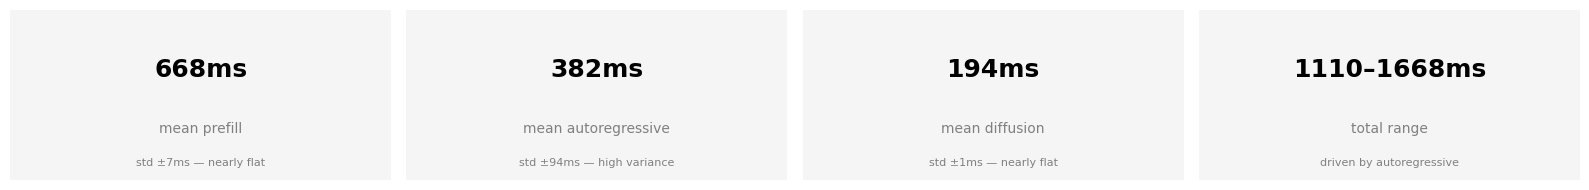

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 2))
fig.patch.set_facecolor('white')
metrics = [
    ("mean prefill",        f"{summary['mean_prefill_ms'].mean():.0f}ms",        f"std ±{summary['mean_prefill_ms'].std():.0f}ms — nearly flat"),
    ("mean autoregressive", f"{summary['mean_autoregressive_ms'].mean():.0f}ms", f"std ±{summary['mean_autoregressive_ms'].std():.0f}ms — high variance"),
    ("mean diffusion",      f"{summary['mean_diffusion_ms'].mean():.0f}ms",       f"std ±{summary['mean_diffusion_ms'].std():.0f}ms — nearly flat"),
    ("total range",         f"{summary['mean_total_ms'].min():.0f}–{summary['mean_total_ms'].max():.0f}ms", "driven by autoregressive"),
]
for ax, (label, value, note) in zip(axes, metrics):
    ax.set_facecolor('#f5f5f5')
    ax.text(0.5, 0.65, value,   ha='center', va='center', fontsize=18, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.30, label,   ha='center', va='center', fontsize=10, color='gray',      transform=ax.transAxes)
    ax.text(0.5, 0.10, note,    ha='center', va='center', fontsize=8,  color='gray',      transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.show()

C_PREFILL = '#378ADD'
C_AR      = '#D85A30'
C_DIFF    = '#1D9E75'

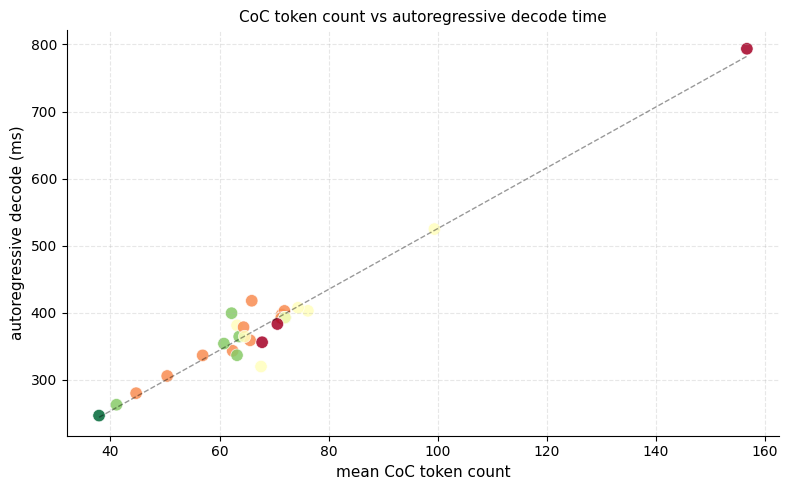

Pearson correlation (token count vs autoregressive ms): 0.979


In [ ]:
##Scatter plot of Autoregressive vs. 
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    summary['mean_coc_token_count'],
    summary['mean_autoregressive_ms'],
    c=summary['complexity_score'], cmap='RdYlGn_r',
    s=80, alpha=0.85, edgecolors='white', linewidths=0.5
)
m, b = np.polyfit(summary['mean_coc_token_count'], summary['mean_autoregressive_ms'], 1)
x_line = np.linspace(summary['mean_coc_token_count'].min(), summary['mean_coc_token_count'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', alpha=0.4, linewidth=1)
ax.set_xlabel('mean CoC token count', fontsize=11)
ax.set_ylabel('autoregressive decode (ms)', fontsize=11)
ax.set_title('CoC token count vs autoregressive decode time', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print correlation
corr = summary['mean_coc_token_count'].corr(summary['mean_autoregressive_ms'])
print(f"Pearson correlation (token count vs autoregressive ms): {corr:.3f}")

In [17]:
cols_of_interest = [
    'mean_coc_token_count',
    'mean_autoregressive_ms',
    'mean_prefill_ms',
    'mean_diffusion_ms',
    'mean_total_ms',
    'complexity_score',
    'mean_minADE',
]

corr_matrix = summary[cols_of_interest].corr()
print(corr_matrix.round(3))

                        mean_coc_token_count  mean_autoregressive_ms  \
mean_coc_token_count                   1.000                   0.979   
mean_autoregressive_ms                 0.979                   1.000   
mean_prefill_ms                        0.096                   0.075   
mean_diffusion_ms                      0.149                   0.142   
mean_total_ms                          0.978                   0.997   
complexity_score                       0.384                   0.368   
mean_minADE                            0.170                   0.135   

                        mean_prefill_ms  mean_diffusion_ms  mean_total_ms  \
mean_coc_token_count              0.096              0.149          0.978   
mean_autoregressive_ms            0.075              0.142          0.997   
mean_prefill_ms                   1.000              0.097          0.148   
mean_diffusion_ms                 0.097              1.000          0.162   
mean_total_ms                     0.14

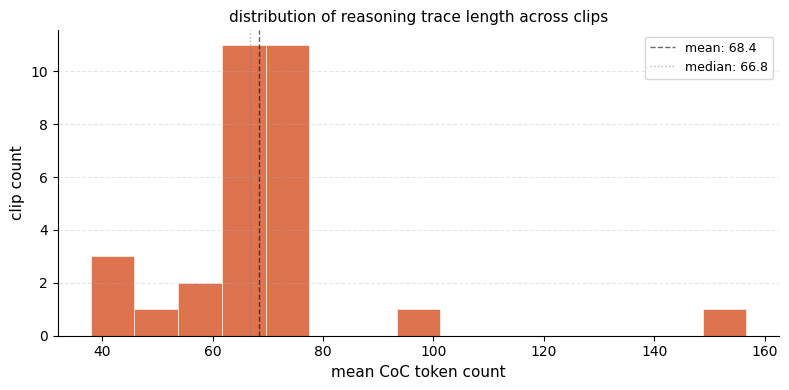

min:    37.9 tokens
max:    156.7 tokens
std:    20.3 tokens


In [ ]:
#Token count distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(summary['mean_coc_token_count'], bins=15, color=C_AR, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(summary['mean_coc_token_count'].mean(), color='black', linestyle='--', linewidth=1, alpha=0.6, label=f"mean: {summary['mean_coc_token_count'].mean():.1f}")
ax.axvline(summary['mean_coc_token_count'].median(), color='gray', linestyle=':', linewidth=1, alpha=0.6, label=f"median: {summary['mean_coc_token_count'].median():.1f}")
ax.set_xlabel('mean CoC token count', fontsize=11)
ax.set_ylabel('clip count', fontsize=11)
ax.set_title('distribution of reasoning trace length across clips', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

print(f"min:    {summary['mean_coc_token_count'].min():.1f} tokens")
print(f"max:    {summary['mean_coc_token_count'].max():.1f} tokens")
print(f"std:    {summary['mean_coc_token_count'].std():.1f} tokens")

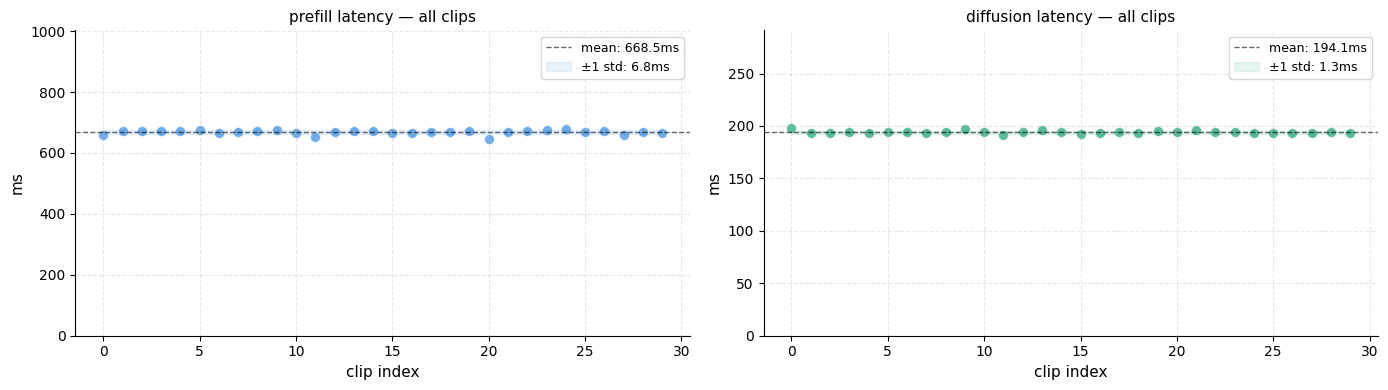

prefill  — mean: 668.5ms  std: 6.8ms  cv: 1.0%
diffusion — mean: 194.1ms  std: 1.3ms  cv: 0.7%


In [ ]:
#Prefill and diffusion flatness
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clips = np.arange(len(summary))

for ax, col, color, label in [
    (axes[0], 'mean_prefill_ms',   C_PREFILL, 'prefill'),
    (axes[1], 'mean_diffusion_ms', C_DIFF,    'diffusion'),
]:
    mean_val = summary[col].mean()
    std_val  = summary[col].std()
    ax.scatter(clips, summary[col], color=color, alpha=0.7, s=50, edgecolors='white', linewidths=0.5)
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f"mean: {mean_val:.1f}ms")
    ax.fill_between(clips, mean_val - std_val, mean_val + std_val, alpha=0.1, color=color, label=f"±1 std: {std_val:.1f}ms")
    ax.set_xlabel('clip index', fontsize=11)
    ax.set_ylabel('ms', fontsize=11)
    ax.set_title(f'{label} latency — all clips', fontsize=11)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, mean_val * 1.5)

plt.tight_layout()
plt.show()

print(f"prefill  — mean: {summary['mean_prefill_ms'].mean():.1f}ms  std: {summary['mean_prefill_ms'].std():.1f}ms  cv: {summary['mean_prefill_ms'].std()/summary['mean_prefill_ms'].mean()*100:.1f}%")
print(f"diffusion — mean: {summary['mean_diffusion_ms'].mean():.1f}ms  std: {summary['mean_diffusion_ms'].std():.1f}ms  cv: {summary['mean_diffusion_ms'].std()/summary['mean_diffusion_ms'].mean()*100:.1f}%")

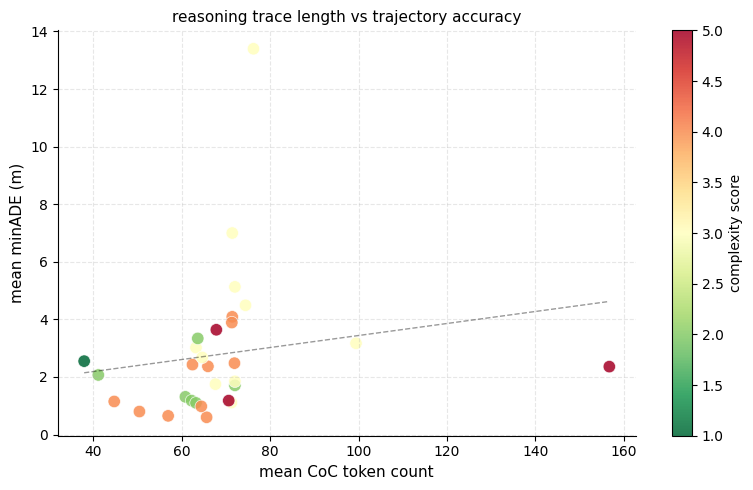

Pearson correlation (token count vs minADE): 0.170
Slope: 0.0209 meters per token


In [23]:

#minADE vs token count
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    summary['mean_coc_token_count'],
    summary['mean_minADE'],
    c=summary['complexity_score'], cmap='RdYlGn_r',
    s=80, alpha=0.85, edgecolors='white', linewidths=0.5
)

m, b = np.polyfit(summary['mean_coc_token_count'], summary['mean_minADE'], 1)
x_line = np.linspace(summary['mean_coc_token_count'].min(), summary['mean_coc_token_count'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', alpha=0.4, linewidth=1)

plt.colorbar(sc, ax=ax, label='complexity score')
ax.set_xlabel('mean CoC token count', fontsize=11)
ax.set_ylabel('mean minADE (m)', fontsize=11)
ax.set_title('reasoning trace length vs trajectory accuracy', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

corr = summary['mean_coc_token_count'].corr(summary['mean_minADE'])
print(f"Pearson correlation (token count vs minADE): {corr:.3f}")
print(f"Slope: {m:.4f} meters per token")

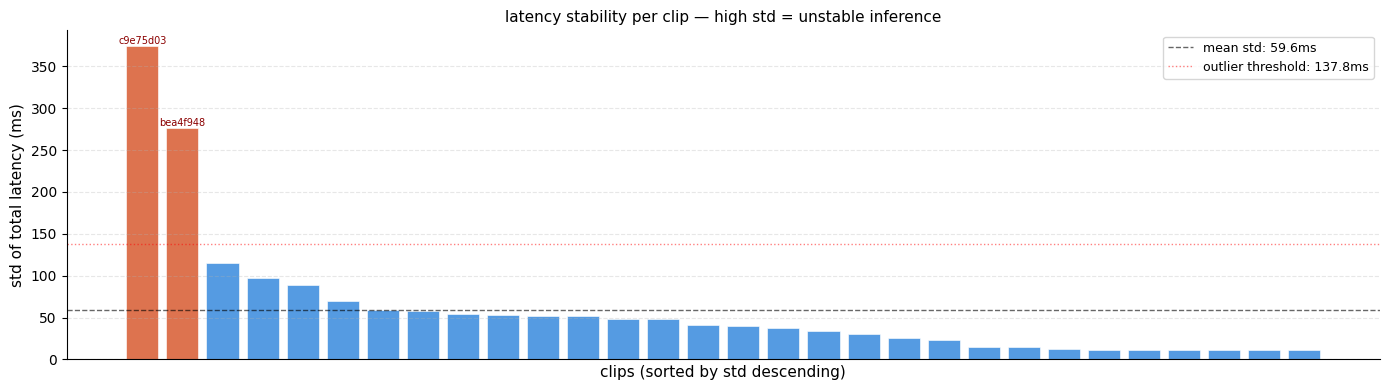

Unstable clips (std > threshold):
                             clip_id  complexity_score  std_total_ms  mean_coc_token_count
c9e75d03-6d05-4295-ab9d-3c2b904bc4f8                 5        374.26                 156.7
bea4f948-bf4e-4763-8a85-bdadb7c863aa                 3        276.61                  99.4


In [24]:
fig, ax = plt.subplots(figsize=(14, 4))

sorted_std = summary.sort_values('std_total_ms', ascending=False).reset_index(drop=True)

threshold = sorted_std['std_total_ms'].mean() + sorted_std['std_total_ms'].std()
colors = [C_AR if v > threshold else C_PREFILL for v in sorted_std['std_total_ms']]

bars = ax.bar(np.arange(len(sorted_std)), sorted_std['std_total_ms'], color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(sorted_std['std_total_ms'].mean(), color='black', linestyle='--', linewidth=1, alpha=0.6, label=f"mean std: {sorted_std['std_total_ms'].mean():.1f}ms")
ax.axhline(threshold, color='red', linestyle=':', linewidth=1, alpha=0.5, label=f"outlier threshold: {threshold:.1f}ms")

# label outlier clip IDs
for i, row in sorted_std.iterrows():
    if row['std_total_ms'] > threshold:
        ax.text(i, row['std_total_ms'] + 2, row['clip_id'][:8], ha='center', fontsize=7, color='darkred')

ax.set_xlabel('clips (sorted by std descending)', fontsize=11)
ax.set_ylabel('std of total latency (ms)', fontsize=11)
ax.set_title('latency stability per clip — high std = unstable inference', fontsize=11)
ax.legend(fontsize=9)
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

print("Unstable clips (std > threshold):")
print(sorted_std[sorted_std['std_total_ms'] > threshold][['clip_id','complexity_score','std_total_ms','mean_coc_token_count']].to_string(index=False))

Above clips have construction cones/ area going on. First clip is likely of a bridge highway at night where only one lane is open and there are construction cones etc. . In the second clip, it is of daytime at a wide highway with a vehicle more than safe distance ahead merging in, but there is a small area to the right as a construction zone with flashing lights.